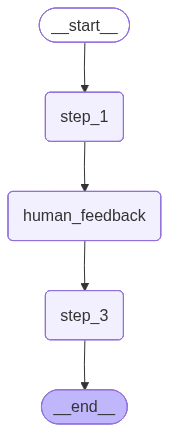

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.types import Command, interrupt
from langgraph.checkpoint.memory import MemorySaver
from IPython.display import Image, display


class State(TypedDict):
    input: str
    user_feedback: str


def step_1(state):
    print("---Step 1---")
    pass


def human_feedback(state):
    print("---human_feedback---")
    feedback = interrupt("Please provide feedback:")
    return {"user_feedback": feedback}


def step_3(state):
    print("---Step 3---")
    pass


builder = StateGraph(State)
builder.add_node("step_1", step_1)
builder.add_node("human_feedback", human_feedback)
builder.add_node("step_3", step_3)
builder.add_edge(START, "step_1")
builder.add_edge("step_1", "human_feedback")
builder.add_edge("human_feedback", "step_3")
builder.add_edge("step_3", END)

# Set up memory
memory = MemorySaver()

# Add
graph = builder.compile(checkpointer=memory)

# View
display(Image(graph.get_graph().draw_mermaid_png()))

In [2]:
# Input
initial_input = {"input": "你好"}

# Thread
thread = {"configurable": {"thread_id": "1"}}

# Run the graph until the first interruption
for event in graph.stream(initial_input, thread, stream_mode="updates"):
    print(event)
    print("\n")

---Step 1---
{'step_1': None}


---human_feedback---
{'__interrupt__': (Interrupt(value='Please provide feedback:', id='4538fc559ff8a6abe07300e9cf636bd3'),)}




In [3]:
# 继续执行
for event in graph.stream(
    Command(resume="go to step 3!"), thread, stream_mode="updates"
):
    print(event)
    print("\n")

---human_feedback---
{'human_feedback': {'user_feedback': 'go to step 3!'}}


---Step 3---
{'step_3': None}




In [ ]:
# 设置状态
from langgraph.graph import MessagesState, START
# 设置工具
# 我们将有一个真实工具 - 搜索工具
# 我们还将有一个"假"工具 - "ask_human"（询问人类）工具
# 这里我们定义任何实际工具
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from dotenv import load_dotenv

@tool
def search(query: str):
    """调用此函数来浏览网络。"""
    # 这只是实际实现的占位符
    # 不要让大语言模型知道这一点哦 😊
    return f"我查询了：{query}。结果：北京天气晴朗，温度25度。"


tools = [search]
tool_node = ToolNode(tools)

# 设置模型
from langchain_deepseek import ChatDeepSeek
import os

load_dotenv()

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    temperature=0,
    api_key=os.environ.get("DEEPSEEK_API_KEY"),
    base_url=os.environ.get("DEEPSEEK_API_BASE"),
)

from pydantic import BaseModel


# 我们将"绑定"所有工具到模型
# 我们有上面的实际工具，但我们还需要一个模拟工具来询问人类
# 由于`bind_tools`接受工具但也接受工具定义，
# 我们可以为`ask_human`定义一个工具定义
class AskHuman(BaseModel):
    """向人类提问"""

    question: str


model = model.bind_tools(tools + [AskHuman])

# 定义节点和条件边


# 定义确定是否继续的函数
def should_continue(state):
    messages = state["messages"]
    last_message = messages[-1]
    # 如果没有函数调用，则结束
    if not last_message.tool_calls:
        return END
    # 如果工具调用是询问人类，我们返回该节点
    # 你也可以在这里添加逻辑，让某些系统知道有需要人类输入的内容
    # 例如，发送slack消息等
    elif last_message.tool_calls[0]["name"] == "AskHuman":
        return "ask_human"
    # 否则如果有函数调用，我们继续
    else:
        return "action"


# 定义调用模型的函数
def call_model(state):
    messages = state["messages"]
    response = model.invoke(messages)
    # 我们返回一个列表，因为这将被添加到现有列表中
    return {"messages": [response]}


# 我们定义一个假节点来询问人类
def ask_human(state):
    tool_call_id = state["messages"][-1].tool_calls[0]["id"]
    ask = AskHuman.model_validate(state["messages"][-1].tool_calls[0]["args"])
    location = interrupt(ask.question)
    tool_message = [{"tool_call_id": tool_call_id, "type": "tool", "content": location}]
    return {"messages": tool_message}


# 构建图

from langgraph.graph import END, StateGraph

# 定义一个新图
workflow = StateGraph(MessagesState)

# 定义我们将循环的三个节点
workflow.add_node("agent", call_model)
workflow.add_node("action", tool_node)
workflow.add_node("ask_human", ask_human)

# 将入口点设置为`agent`
# 这意味着这个节点是第一个被调用的
workflow.add_edge(START, "agent")

# 现在添加一个条件边
workflow.add_conditional_edges(
    # 首先，我们定义起始节点。我们使用`agent`。
    # 这意味着这些是在调用`agent`节点后采取的边。
    "agent",
    # 接下来，我们传入将确定下一个调用哪个节点的函数。
    should_continue,
)

# 现在我们从`tools`到`agent`添加一个普通边。
# 这意味着在调用`tools`之后，下一步调用`agent`节点。
workflow.add_edge("action", "agent")

# 在我们获得人类响应后，我们回到代理
workflow.add_edge("ask_human", "agent")

# 设置内存
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

# 最后，我们编译它！
# 这将它编译成一个LangChain Runnable，
# 意味着你可以像使用任何其他runnable一样使用它
# 我们在`ask_human`节点之前添加一个断点，所以它永远不会执行
app = workflow.compile(checkpointer=memory)

display(Image(app.get_graph().draw_mermaid_png()))